# Project 2: Long/Short Factor-Based GTAA Portfolio
**Factors:** Momentum (12-1) + Low Volatility (12-month)

**Pipeline:**
1. Load data
2. Define backtest dates (10 years, monthly)
3. Build rolling covariance matrices for the backtest period (look back into full history)
4. Build FMP signals and unscaled weights
5. Scale each FMP to 1% annual vol
6. Combine FMPs and re-scale combined portfolio to 1% annual vol
7. Compute returns and summary statistics
8. Charts and required output tables

# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from pandas.tseries.offsets import MonthEnd

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 1. Load Data

In [2]:
df = pd.read_excel('Final_Project2_Data.xlsx')
assert df.isnull().sum().sum() == 0, "DataFrame contains missing values"

returns = (
    df
    .rename(columns={'Total returns in local currency': 'Date'})
    .set_index('Date')
    .sort_index()
)

COUNTRIES = list(returns.columns)

print(f"Start date    : {returns.index.min().date()}")
print(f"End date      : {returns.index.max().date()}")
print(f"Observations  : {len(returns)} months")
print(f"Countries ({len(COUNTRIES)}): {COUNTRIES}")
returns.tail(3)

Start date    : 1970-01-31
End date      : 2025-12-31
Observations  : 672 months
Countries (10): ['MSCI Australia NR LCL', 'MSCI Canada NR LCL', 'MSCI France NR LCL', 'MSCI Germany NR LCL', 'MSCI Italy NR LCL', 'MSCI Japan NR JPY', 'MSCI Netherlands NR LCL', 'MSCI Spain NR LCL', 'MSCI United Kingdom NR LCL', 'MSCI USA NR USD']


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Date,,,,,,,,,,
2025-10-31,0.0019,0.0105,0.0274,-0.0033,0.0119,0.0785,0.0466,0.0370,0.0418,0.0235
2025-11-30,-0.0358,0.0367,0.0012,-0.0017,0.0149,0.0059,-0.0239,0.0300,0.0054,0.0000
2025-12-31,0.0184,0.0127,0.0053,0.0314,0.0344,0.0099,0.0147,0.0584,0.0224,-0.0002


# 2. Define Backtest Period

The backtest is the 10-year window we evaluate the strategy on.  
For **every** month $t$ in this window, we look back into the full return history to form signals and estimate covariances — no separate train/test split.

**Look-ahead rule:** at time $t$ we may only use data through $t-1$.

In [3]:
# 10-year backtest ending at last available date
backtest_end   = returns.index.max()
backtest_start = backtest_end - MonthEnd(119)   # 120 months inclusive

backtest_dates = returns.loc[backtest_start:backtest_end].copy()

print(f"Backtest start : {backtest_dates.index[0].date()}")
print(f"Backtest end   : {backtest_dates.index[-1].date()}")
print(f"Backtest months: {len(backtest_dates)}")
print()
# Verify we have enough history before the backtest for a 36-month cov window
first_t = backtest_dates.index[0]
earliest_needed = first_t - MonthEnd(36)
assert earliest_needed in returns.index, (
    f"Need data back to {earliest_needed.date()} for the 36-month cov window, "
    f"but full history only starts at {returns.index.min().date()}"
)
print(f"History check OK: earliest cov window starts {earliest_needed.date()}")

Backtest start : 2016-01-31
Backtest end   : 2025-12-31
Backtest months: 120

History check OK: earliest cov window starts 2013-01-31


# 3. Rolling Asset Covariance Matrices

For each backtest month $t$:
$$\Sigma_t = 12 \times \operatorname{Cov}\bigl(r_{t-36},\ldots,r_{t-1}\bigr)$$

- Window: 36 months ending at $t-1$ (no look-ahead)
- Annualized by multiplying by 12

In [4]:
def build_asset_cov_matrices(full_returns, target_dates, look_back=36):
    """
    Build rolling annualized covariance matrices.

    Parameters
    ----------
    full_returns : DataFrame
        Complete return history (used as the look-back pool).
    target_dates : DataFrame
        The months we need a covariance matrix FOR (i.e., backtest months).
    look_back : int
        Number of months of prior returns to use per estimate.

    Returns
    -------
    cov_dict  : dict[Timestamp -> DataFrame]  annualized covariance matrices
    vol_dict  : dict[Timestamp -> Series]     annualized vols (sqrt of diag)
    corr_dict : dict[Timestamp -> DataFrame]  correlation matrices
    window_map_df : DataFrame                 audit trail of window dates
    """
    cov_dict, vol_dict, corr_dict, window_map = {}, {}, {}, []

    for t in target_dates.index:
        start = t - MonthEnd(look_back)   # e.g. 36 months back
        end   = t - MonthEnd(1)           # last month before t (no look-ahead)

        assert start in full_returns.index, f"{start.date()} not in returns index"
        assert end   in full_returns.index, f"{end.date()} not in returns index"

        window = full_returns.loc[start:end]
        assert len(window) == look_back, (
            f"Expected {look_back} rows at {t.date()}, got {len(window)}"
        )

        cov_t  = window.cov() * 12
        vol_t  = pd.Series(np.sqrt(np.diag(cov_t)), index=cov_t.index, name=t)
        corr_t = window.corr()

        cov_dict[t]  = cov_t
        vol_dict[t]  = vol_t
        corr_dict[t] = corr_t
        window_map.append({'Date': t, 'cov_start': start, 'cov_end': end})

    window_map_df = pd.DataFrame(window_map).set_index('Date')
    return cov_dict, vol_dict, corr_dict, window_map_df

# 4a. Factor 1 — Momentum (12-1)

For country $i$ at backtest month $t$, the momentum signal is the cumulative return over $[t-12, t-2]$ (skipping the most recent month to avoid short-term reversal):

$$\text{Mom}_{i,t}^{12\text{-}1} = \prod_{k=2}^{12}(1+r_{i,t-k}) - 1$$

**Weights:** demean the signal cross-sectionally, then normalize so gross exposure $= 1$:
$$w_{i,t}^{\text{raw}} = \frac{\text{Mom}_{i,t} - \bar{\text{Mom}}_t}{\sum_j |\text{Mom}_{j,t} - \bar{\text{Mom}}_t|}$$

In [5]:
def build_momentum_factor(full_returns, target_dates, start_lag=12, end_lag=2, name='mom121'):
    """
    Compute momentum FMP for all dates in target_dates.

    Parameters
    ----------
    full_returns : DataFrame  complete return history
    target_dates : DataFrame  backtest months
    start_lag    : int        beginning of lookback window (months before t)
    end_lag      : int        end of lookback window (months before t)
                              e.g. start_lag=12, end_lag=2  =>  [t-12, t-2]

    Returns
    -------
    signals_df          : DataFrame  raw cumulative returns + window dates
    unscaled_weights_df : DataFrame  demeaned, gross-exposure-normalized weights
    """
    rows = []
    for t in target_dates.index:
        start = t - MonthEnd(start_lag)
        end   = t - MonthEnd(end_lag)

        assert start in full_returns.index, f"{start.date()} not in index"
        assert end   in full_returns.index, f"{end.date()} not in index"

        window = full_returns.loc[start:end]
        signal = (1 + window).prod(axis=0) - 1
        signal.name = t
        rows.append({'t': t, 'start': start, 'end': end, 'signal': signal})

    signals_df = pd.DataFrame(
        {r['t']: r['signal'] for r in rows}
    ).T
    signals_df.index.name = 'Date'

    # Add audit columns
    signals_df.insert(0, 'start', [r['start'] for r in rows])
    signals_df.insert(1, 'end',   [r['end']   for r in rows])

    country_cols = signals_df.columns[2:]
    sig = signals_df[country_cols]

    demeaned  = sig.sub(sig.mean(axis=1), axis=0)
    abs_sum   = demeaned.abs().sum(axis=1).replace(0, np.nan)
    unscaled_weights_df = demeaned.div(abs_sum, axis=0).fillna(0.0)

    return signals_df, unscaled_weights_df

# 4b. Factor 2 — Low Volatility (12-month)

For country $i$ at backtest month $t$, the signal is the **negative** annualized volatility over the prior 12 months:

$$\text{LV}_{i,t}^{(12)} = -\sqrt{12} \cdot \text{SD}\bigl(r_{i,t-12},\ldots,r_{i,t-1}\bigr)$$

Lower vol $\Rightarrow$ higher signal $\Rightarrow$ larger long weight.

**Weights:** same demean + normalize scheme as momentum.

In [6]:
def build_lowvol_factor(full_returns, target_dates, look_back=12, name='lv'):
    """
    Compute low-volatility FMP for all dates in target_dates.

    Parameters
    ----------
    full_returns : DataFrame  complete return history
    target_dates : DataFrame  backtest months
    look_back    : int        volatility estimation window (months before t)
                              window = [t-look_back, t-1]

    Returns
    -------
    signals_df          : DataFrame  annualized vol signals + window dates
    unscaled_weights_df : DataFrame  demeaned, gross-exposure-normalized weights
    """
    rows = []
    for t in target_dates.index:
        start = t - MonthEnd(look_back)
        end   = t - MonthEnd(1)

        assert start in full_returns.index, f"{start.date()} not in index"
        assert end   in full_returns.index, f"{end.date()} not in index"

        window = full_returns.loc[start:end]
        assert len(window) == look_back, (
            f"Expected {look_back} rows at {t.date()}, got {len(window)}"
        )

        # Negative annualized vol: lower vol => higher signal
        signal = -(window.std(axis=0) * np.sqrt(12))
        signal.name = t
        rows.append({'t': t, 'start': start, 'end': end, 'signal': signal})

    signals_df = pd.DataFrame(
        {r['t']: r['signal'] for r in rows}
    ).T
    signals_df.index.name = 'Date'
    signals_df.insert(0, 'start', [r['start'] for r in rows])
    signals_df.insert(1, 'end',   [r['end']   for r in rows])

    country_cols = signals_df.columns[2:]
    sig = signals_df[country_cols]

    demeaned  = sig.sub(sig.mean(axis=1), axis=0)
    abs_sum   = demeaned.abs().sum(axis=1).replace(0, np.nan)
    unscaled_weights_df = demeaned.div(abs_sum, axis=0).fillna(0.0)

    return signals_df, unscaled_weights_df

# 5. Scale FMP Weights to Target 1% Annual Volatility

Given raw weights $w_t^{\text{raw}}$ and annualized covariance $\Sigma_t$:

$$\sigma_t^{\text{raw}} = \sqrt{(w_t^{\text{raw}})^\top \Sigma_t\, w_t^{\text{raw}}}$$

$$w_t^{\text{scaled}} = w_t^{\text{raw}} \times \frac{0.01}{\sigma_t^{\text{raw}}}$$

In [7]:
def scale_factor_to_target_vol(unscaled_weights_df, cov_dict, target_vol=0.01):
    """
    Scale FMP weights so the ex-ante portfolio vol equals target_vol.

    Parameters
    ----------
    unscaled_weights_df : DataFrame  raw FMP weights (index = backtest dates)
    cov_dict            : dict       annualized covariance matrices keyed by date
    target_vol          : float      target annual volatility (default 0.01 = 1%)

    Returns
    -------
    scaled_weights_df : DataFrame  scaled weights
    portfolio_risk_s  : Series     ex-ante raw vol before scaling (for audit)
    """
    cols = unscaled_weights_df.columns
    scaled_rows, risks = [], []

    for t in unscaled_weights_df.index:
        w     = unscaled_weights_df.loc[t].values
        cov_t = cov_dict[t].loc[cols, cols].values

        raw_vol = np.sqrt(w @ cov_t @ w)
        assert raw_vol > 0, f"Zero raw vol at {t.date()} — check weights"

        scaled_rows.append(w * (target_vol / raw_vol))
        risks.append(raw_vol)

    scaled_weights_df = pd.DataFrame(
        scaled_rows, index=unscaled_weights_df.index, columns=cols
    )
    portfolio_risk_s = pd.Series(
        risks, index=unscaled_weights_df.index, name='raw_vol_before_scaling'
    )
    return scaled_weights_df, portfolio_risk_s

# 6. Compute Realized Returns

Weight $w_{i,t}$ is formed using only data through $t-1$, then applied to the return realized in month $t$.

In [8]:
def compute_factor_returns(scaled_weights_df, target_dates, name='factor_return'):
    """
    Compute realized monthly returns: r_portfolio_t = w_t' * r_t

    Strict index alignment check is enforced — no silent NaN fill.

    Parameters
    ----------
    scaled_weights_df : DataFrame  weights indexed by backtest month
    target_dates      : DataFrame  realized returns for the same months
    name              : str        name for the returned Series

    Returns
    -------
    Series of monthly portfolio returns
    """
    assert scaled_weights_df.index.equals(target_dates.index), (
        "Index mismatch between weights and returns — check your backtest_dates slice"
    )
    cols = scaled_weights_df.columns
    factor_returns = (target_dates[cols] * scaled_weights_df).sum(axis=1)
    factor_returns.name = name
    return factor_returns

# 7. Combine FMPs and Re-Scale Portfolio

Equal-weight combination of the two scaled FMPs, then the combined weights are re-scaled to 1% vol:

$$w_t^{\text{combined}} = 0.5 \cdot w_t^{\text{Mom}} + 0.5 \cdot w_t^{\text{LV}}$$

$$w_t^{\text{final}} = w_t^{\text{combined}} \times \frac{0.01}{\sqrt{(w_t^{\text{combined}})^\top \Sigma_t\, w_t^{\text{combined}}}}$$

In [9]:
def combine_fmps(weight_dfs, cov_dict, fmp_weights=None, target_vol=0.01):
    """
    Combine multiple FMPs (already scaled to 1% each) and re-scale the
    combined portfolio to target_vol.

    Parameters
    ----------
    weight_dfs  : list of DataFrames   each is a 1%-scaled FMP weight df
    cov_dict    : dict                 annualized covariance matrices
    fmp_weights : list of float        mixing weights (default: equal)
    target_vol  : float                final portfolio target vol

    Returns
    -------
    combined_raw_df : DataFrame  pre-rescale combined weights
    final_df        : DataFrame  final 1%-vol portfolio weights
    final_risk_s    : Series     ex-ante vol before final rescaling
    """
    n = len(weight_dfs)
    if fmp_weights is None:
        fmp_weights = [1.0 / n] * n
    assert abs(sum(fmp_weights) - 1.0) < 1e-9, "FMP mixing weights must sum to 1"

    combined_raw_df = sum(w * df for w, df in zip(fmp_weights, weight_dfs))

    final_df, final_risk_s = scale_factor_to_target_vol(
        combined_raw_df, cov_dict, target_vol=target_vol
    )
    return combined_raw_df, final_df, final_risk_s

# 8. Summary Statistics

In [10]:
def portfolio_statistics(returns_s, name=None):
    """
    Compute required summary statistics from a monthly return Series.

    Returns a Series with:
      - Arithmetic Annualized Return
      - Annualized Volatility
      - Information Ratio (ann. return / ann. vol)
      - Average Drawdown
      - Maximum Drawdown
      - Monthly Turnover (average absolute weight change, annualized)
    """
    ann_ret = returns_s.mean() * 12
    ann_vol = returns_s.std()  * np.sqrt(12)
    ir      = ann_ret / ann_vol if ann_vol != 0 else np.nan

    growth  = (1 + returns_s).cumprod()
    dd      = growth / growth.cummax() - 1
    avg_dd  = dd.mean()
    max_dd  = dd.min()

    stats = pd.Series({
        'Arithmetic Annualized Return': ann_ret,
        'Annualized Volatility':        ann_vol,
        'Information Ratio':            ir,
        'Average Drawdown':             avg_dd,
        'Maximum Drawdown':             max_dd,
    }, name=name or returns_s.name)
    return stats


def compute_turnover(weights_df):
    """
    Average monthly one-way turnover: mean over time of sum_i |w_{i,t} - w_{i,t-1}|
    Annualized by multiplying by 12.
    """
    monthly = weights_df.diff().abs().sum(axis=1).iloc[1:]
    return monthly.mean() * 12

# 9. Run the Full Backtest Pipeline

In [11]:
# ── 9.1  Rolling covariance matrices (for every backtest month) ──────────────
print("Building covariance matrices...")
cov_dict, vol_dict, corr_dict, window_map_df = build_asset_cov_matrices(
    full_returns  = returns,        # full history back to 1970 as look-back pool
    target_dates  = backtest_dates, # only need a matrix for each backtest month
    look_back     = 36
)
print(f"  Covariance matrices built for {len(cov_dict)} months")

# ── 9.2  Momentum 12-1 ───────────────────────────────────────────────────────
print("\nBuilding Momentum (12-1) factor...")
mom_signals_df, mom_unscaled_df = build_momentum_factor(
    full_returns  = returns,
    target_dates  = backtest_dates,
    start_lag     = 12,
    end_lag       = 2,
    name          = 'mom121'
)
mom_scaled_df, mom_raw_risk = scale_factor_to_target_vol(
    mom_unscaled_df, cov_dict, target_vol=0.01
)
mom_returns = compute_factor_returns(mom_scaled_df, backtest_dates, name='Mom 12-1')
print(f"  Done. Rows: {len(mom_returns)}")

# ── 9.3  Low Volatility 12 ───────────────────────────────────────────────────
print("\nBuilding Low Volatility (12m) factor...")
lv_signals_df, lv_unscaled_df = build_lowvol_factor(
    full_returns  = returns,
    target_dates  = backtest_dates,
    look_back     = 12,
    name          = 'lv12'
)
lv_scaled_df, lv_raw_risk = scale_factor_to_target_vol(
    lv_unscaled_df, cov_dict, target_vol=0.01
)
lv_returns = compute_factor_returns(lv_scaled_df, backtest_dates, name='Low Vol 12m')
print(f"  Done. Rows: {len(lv_returns)}")

# ── 9.4  Combined portfolio ───────────────────────────────────────────────────
print("\nCombining FMPs and rescaling to 1% vol...")
combined_raw_df, final_weights_df, final_risk = combine_fmps(
    weight_dfs  = [mom_scaled_df, lv_scaled_df],
    cov_dict    = cov_dict,
    fmp_weights = [0.5, 0.5],
    target_vol  = 0.01
)
portfolio_returns = compute_factor_returns(
    final_weights_df, backtest_dates, name='Combined Portfolio'
)
print(f"  Done. Rows: {len(portfolio_returns)}")

print("\n✓ Pipeline complete.")

Building covariance matrices...
  Covariance matrices built for 120 months

Building Momentum (12-1) factor...
  Done. Rows: 120

Building Low Volatility (12m) factor...
  Done. Rows: 120

Combining FMPs and rescaling to 1% vol...
  Done. Rows: 120

✓ Pipeline complete.


# 10. Summary Statistics Table

In [12]:
# Compute statistics for each series
stats_list = []
for ret_s, wt_df, label in [
    (mom_returns,       mom_scaled_df,   'Mom 12-1'),
    (lv_returns,        lv_scaled_df,    'Low Vol 12m'),
    (portfolio_returns, final_weights_df,'Combined Portfolio'),
]:
    s = portfolio_statistics(ret_s, name=label)
    s['Annualized Turnover'] = compute_turnover(wt_df)
    stats_list.append(s)

stats_df = pd.DataFrame(stats_list)

# Format for display
pct_cols = ['Arithmetic Annualized Return', 'Annualized Volatility',
            'Average Drawdown', 'Maximum Drawdown', 'Annualized Turnover']
fmt = stats_df.copy()
for c in pct_cols:
    fmt[c] = fmt[c].map(lambda x: f"{x:.2%}")
fmt['Information Ratio'] = fmt['Information Ratio'].map(lambda x: f"{x:.3f}")

print("=" * 70)
print("PORTFOLIO STATISTICS")
print("=" * 70)
display(fmt.T)


PORTFOLIO STATISTICS


,Mom 12-1,Low Vol 12m,Combined Portfolio
Arithmetic Annualized Return,0.04%,0.21%,0.20%
Annualized Volatility,1.18%,1.03%,1.14%
Information Ratio,0.031,0.206,0.178
Average Drawdown,-1.40%,-0.85%,-0.75%
Maximum Drawdown,-3.14%,-2.04%,-2.41%
Annualized Turnover,138.88%,60.88%,119.95%


# 11. Charts

## 11a. Growth of $1 — All Strategies

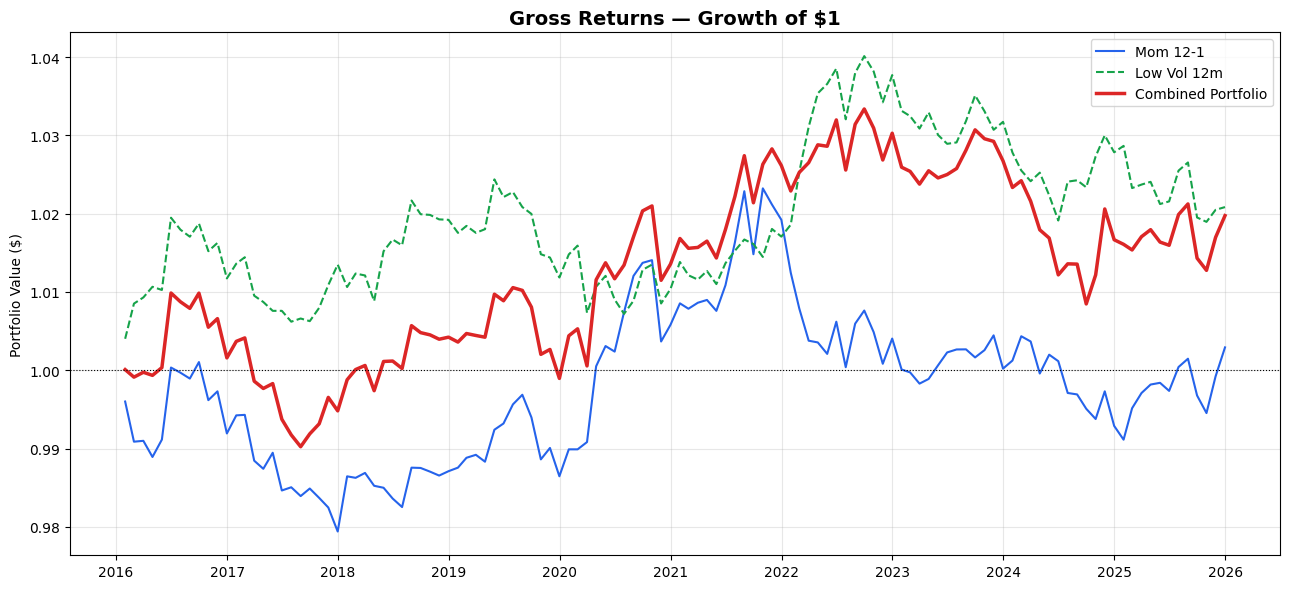

In [13]:
all_returns = pd.DataFrame({
    'Mom 12-1':          mom_returns,
    'Low Vol 12m':       lv_returns,
    'Combined Portfolio': portfolio_returns,
})

growth = (1 + all_returns).cumprod()

fig, ax = plt.subplots(figsize=(13, 6))
colors = {'Mom 12-1': '#2563EB', 'Low Vol 12m': '#16A34A', 'Combined Portfolio': '#DC2626'}
styles = {'Mom 12-1': '-',        'Low Vol 12m': '--',      'Combined Portfolio': '-'}
widths = {'Mom 12-1': 1.5,        'Low Vol 12m': 1.5,       'Combined Portfolio': 2.5}

for col in growth.columns:
    ax.plot(growth.index, growth[col],
            label=col, color=colors[col],
            linestyle=styles[col], linewidth=widths[col])

ax.axhline(1, color='black', linewidth=0.8, linestyle=':')
ax.set_title('Gross Returns — Growth of $1', fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Value ($)')
ax.set_xlabel('')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('growth_of_1.png', dpi=150, bbox_inches='tight')
plt.show()

## 11b. Drawdown Chart

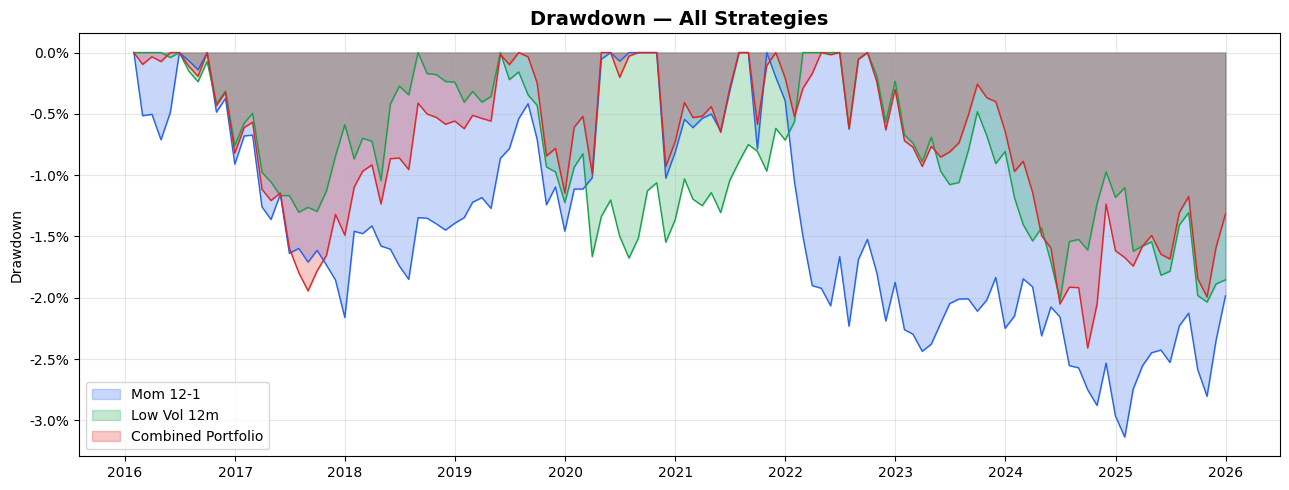

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))

for col in growth.columns:
    dd = growth[col] / growth[col].cummax() - 1
    ax.fill_between(dd.index, dd, 0,
                    alpha=0.25, color=colors[col], label=col)
    ax.plot(dd.index, dd, color=colors[col], linewidth=1)

ax.set_title('Drawdown — All Strategies', fontsize=14, fontweight='bold')
ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.savefig('drawdowns.png', dpi=150, bbox_inches='tight')
plt.show()

## 11c. Factor 1 — Momentum 1%-Vol Weights Over Time

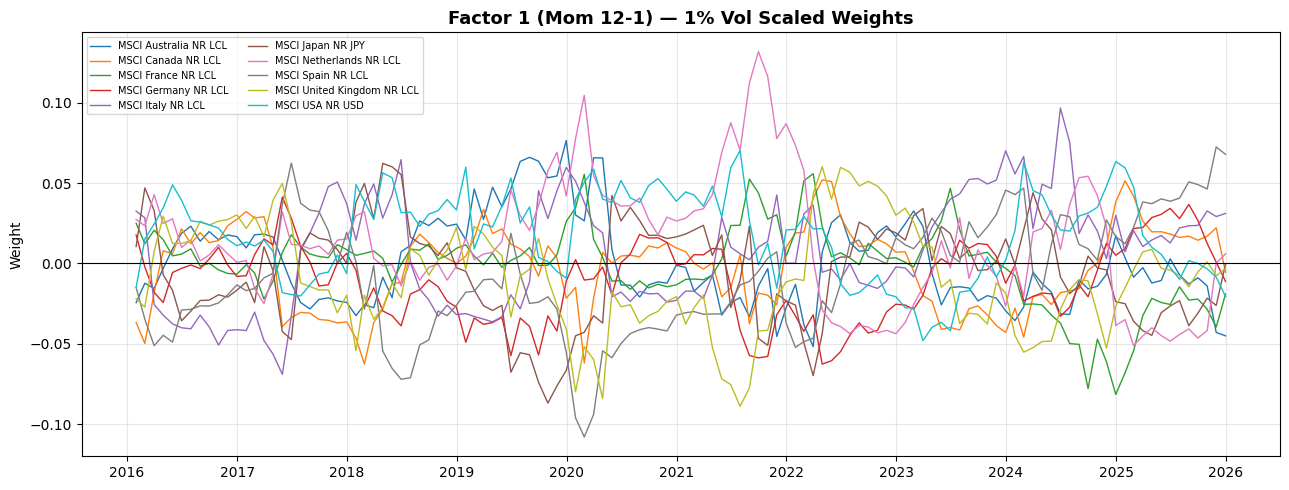

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
for col in mom_scaled_df.columns:
    ax.plot(mom_scaled_df.index, mom_scaled_df[col], label=col, linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Factor 1 (Mom 12-1) — 1% Vol Scaled Weights', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight')
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('mom_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 11d. Factor 2 — Low Vol 1%-Vol Weights Over Time

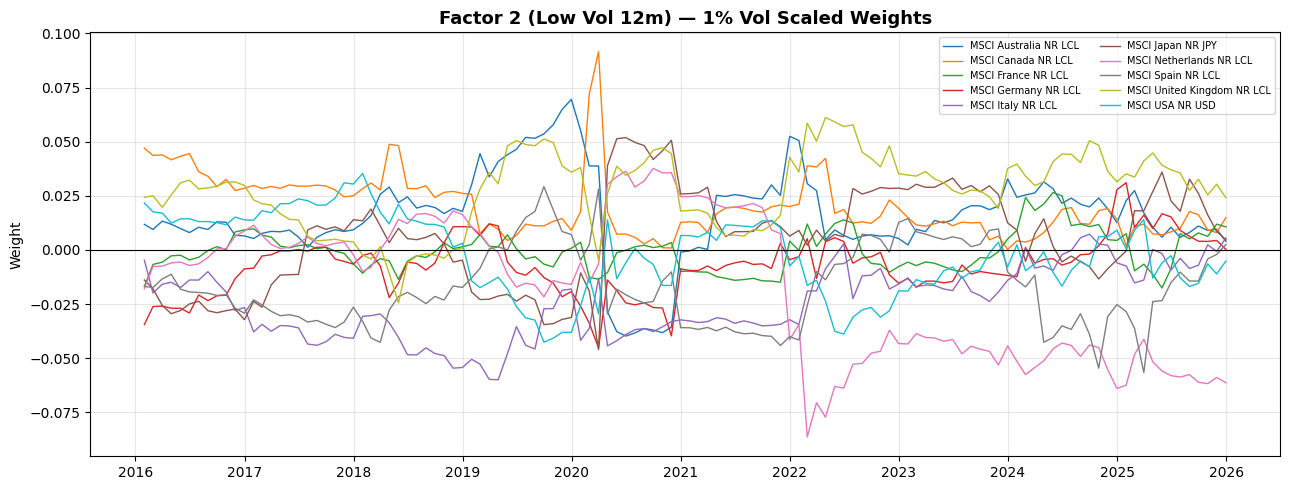

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
for col in lv_scaled_df.columns:
    ax.plot(lv_scaled_df.index, lv_scaled_df[col], label=col, linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Factor 2 (Low Vol 12m) — 1% Vol Scaled Weights', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight')
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('lv_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 11e. Final Combined Portfolio Weights Over Time

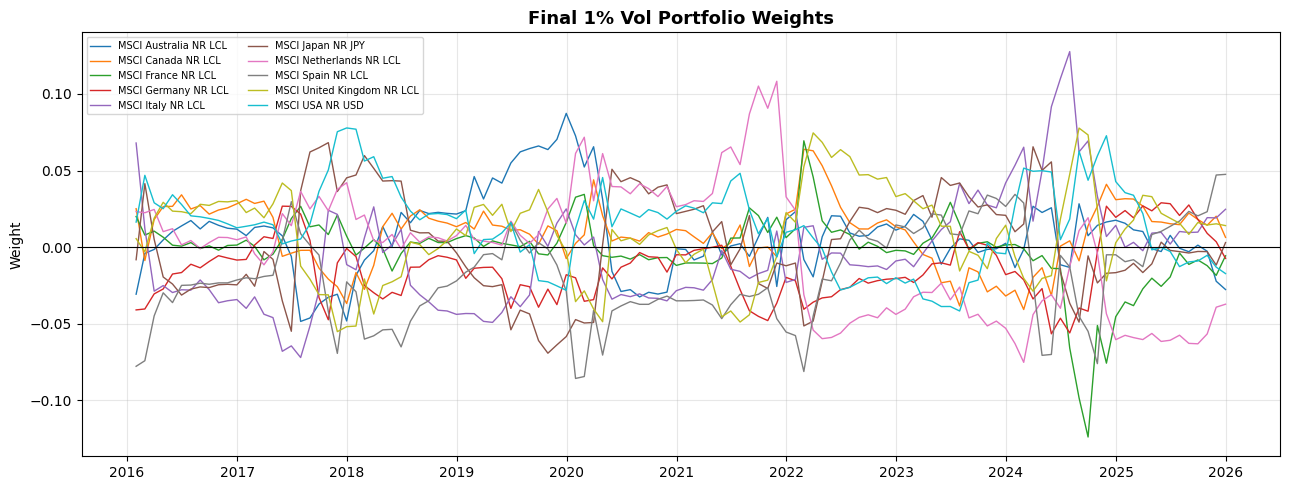

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
for col in final_weights_df.columns:
    ax.plot(final_weights_df.index, final_weights_df[col], label=col, linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Final 1% Vol Portfolio Weights', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight')
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('final_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 11f. Stacked Area — Final Portfolio Weights (shows long vs short)

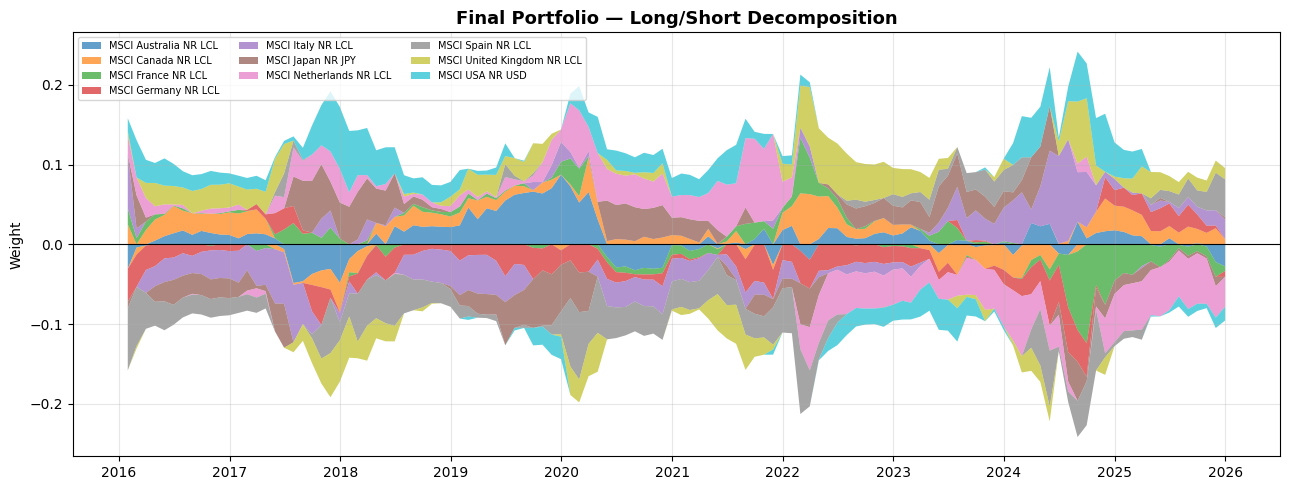

In [18]:
pos = final_weights_df.clip(lower=0)
neg = final_weights_df.clip(upper=0)

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(final_weights_df.index, pos.T,
             labels=final_weights_df.columns, alpha=0.7)
ax.stackplot(final_weights_df.index, neg.T, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Final Portfolio — Long/Short Decomposition', fontsize=13, fontweight='bold')
ax.set_ylabel('Weight')
ax.legend(fontsize=7, ncol=3, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('final_weights_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. Required Output Tables (Assignment Section 6 & 7)

In [ ]:
#  Raw Factor Weights (before vol scaling) 
print("RAW FACTOR WEIGHTS — Momentum 12-1 (first 5 rows)")
display(mom_unscaled_df.head())

print("\nRAW FACTOR WEIGHTS — Low Vol 12m (first 5 rows)")
display(lv_unscaled_df.head())

RAW FACTOR WEIGHTS — Momentum 12-1 (first 5 rows)


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Date,,,,,,,,,,
2016-01-31,-0.107928,-0.162205,0.110566,0.078100,0.143875,0.046441,0.121017,-0.066342,-0.097309,-0.066217
2016-02-29,-0.048807,-0.197179,0.048258,-0.008781,0.112335,0.186155,0.092708,-0.137540,-0.107693,0.060544
2016-03-31,-0.060488,-0.070152,0.080423,-0.070167,-0.099653,0.128009,0.166676,-0.199541,0.029210,0.095682
2016-04-30,-0.014090,0.035515,0.066235,-0.109144,-0.144233,-0.032041,0.111607,-0.200492,0.131798,0.154845
2016-05-31,0.041597,0.027620,0.021599,-0.025924,-0.172555,-0.076735,0.127534,-0.224786,0.057169,0.224481



RAW FACTOR WEIGHTS — Low Vol 12m (first 5 rows)


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Date,,,,,,,,,,
2016-01-31,0.056447,0.224244,-0.080425,-0.164593,-0.022636,-0.066317,-0.085512,-0.080517,0.115902,0.103408
2016-02-29,0.049400,0.228041,-0.034935,-0.136600,-0.103918,-0.093868,-0.040142,-0.090537,0.130744,0.091814
2016-03-31,0.070844,0.233744,-0.030228,-0.138115,-0.084256,-0.136398,-0.039782,-0.071222,0.104793,0.090619
2016-04-30,0.064987,0.228073,-0.014897,-0.147473,-0.081755,-0.161364,-0.032936,-0.061574,0.138998,0.067942
2016-05-31,0.050167,0.219593,-0.012420,-0.136803,-0.088239,-0.142067,-0.028397,-0.092073,0.157402,0.072839


In [ ]:
#  1% Vol Weights 
print("FACTOR 1 — 1% VOL WEIGHTS (Mom 12-1, first 5 rows)")
display(mom_scaled_df.head())

print("\nFACTOR 2 — 1% VOL WEIGHTS (Low Vol 12m, first 5 rows)")
display(lv_scaled_df.head())

print("\nFINAL 1% VOL PORTFOLIO WEIGHTS (first 5 rows)")
display(final_weights_df.head())

FACTOR 1 — 1% VOL WEIGHTS (Mom 12-1, first 5 rows)


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Date,,,,,,,,,,
2016-01-31,-0.024426,-0.036710,0.025023,0.017675,0.032562,0.010510,0.027388,-0.015014,-0.022023,-0.014986
2016-02-29,-0.012330,-0.049813,0.012191,-0.002218,0.028379,0.047028,0.023421,-0.034747,-0.027206,0.015295
2016-03-31,-0.015531,-0.018012,0.020649,-0.018015,-0.025586,0.032867,0.042795,-0.051233,0.007500,0.024567
2016-04-30,-0.003142,0.007920,0.014771,-0.024341,-0.032166,-0.007146,0.024890,-0.044712,0.029393,0.034533
2016-05-31,0.009067,0.006021,0.004708,-0.005651,-0.037614,-0.016727,0.027801,-0.049000,0.012462,0.048933



FACTOR 2 — 1% VOL WEIGHTS (Low Vol 12m, first 5 rows)


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Date,,,,,,,,,,
2016-01-31,0.011824,0.046972,-0.016846,-0.034477,-0.004741,-0.013891,-0.017912,-0.016866,0.024278,0.021660
2016-02-29,0.009456,0.043653,-0.006688,-0.026149,-0.019893,-0.017969,-0.007684,-0.017331,0.025028,0.017576
2016-03-31,0.013305,0.043899,-0.005677,-0.025939,-0.015824,-0.025617,-0.007471,-0.013376,0.019681,0.017019
2016-04-30,0.011864,0.041638,-0.002720,-0.026923,-0.014926,-0.029459,-0.006013,-0.011241,0.025376,0.012404
2016-05-31,0.009877,0.043235,-0.002445,-0.026935,-0.017373,-0.027971,-0.005591,-0.018128,0.030990,0.014341



FINAL 1% VOL PORTFOLIO WEIGHTS (first 5 rows)


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Date,,,,,,,,,,
2016-01-31,-0.030792,0.025073,0.019978,-0.041051,0.067973,-0.008261,0.023154,-0.077893,0.005509,0.016308
2016-02-29,-0.004097,-0.008782,0.007847,-0.040443,0.012099,0.041430,0.022435,-0.074248,-0.003106,0.046864
2016-03-31,-0.001548,0.018011,0.010417,-0.030581,-0.028811,0.005044,0.024576,-0.044951,0.018911,0.028933
2016-04-30,0.004658,0.026469,0.006437,-0.027380,-0.025152,-0.019551,0.010082,-0.029885,0.029252,0.025069
2016-05-31,0.010236,0.026612,0.001223,-0.017606,-0.029709,-0.024150,0.012000,-0.036269,0.023477,0.034187


In [ ]:
# Final Period: Covariances, Volatilities, Correlations 
last_t = backtest_dates.index[-1]

print(f"FINAL PERIOD: {last_t.date()}")
print("\nAnnualized Covariance Matrix:")
display(cov_dict[last_t].round(6))

print("\nAnnualized Volatilities (from diagonal of covariance):")
display(vol_dict[last_t].rename('Annualized Vol').to_frame().T.round(4))

print("\nCorrelation Matrix:")
display(corr_dict[last_t].round(4))

FINAL PERIOD: 2025-12-31

Annualized Covariance Matrix:


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
MSCI Australia NR LCL,0.011517,0.009545,0.006944,0.009278,0.006715,0.008094,0.009429,0.005906,0.004704,0.010544
MSCI Canada NR LCL,0.009545,0.014312,0.009164,0.010175,0.009795,0.008779,0.010671,0.009891,0.006499,0.012228
MSCI France NR LCL,0.006944,0.009164,0.014006,0.012365,0.013640,0.007714,0.013312,0.012731,0.007110,0.008893
MSCI Germany NR LCL,0.009278,0.010175,0.012365,0.015390,0.013218,0.007430,0.014458,0.012946,0.006116,0.011304
MSCI Italy NR LCL,0.006715,0.009795,0.013640,0.013218,0.017729,0.007215,0.012262,0.015079,0.007610,0.009320
MSCI Japan NR JPY,0.008094,0.008779,0.007714,0.007430,0.007215,0.014146,0.013756,0.006700,0.003488,0.010786
MSCI Netherlands NR LCL,0.009429,0.010671,0.013312,0.014458,0.012262,0.013756,0.035207,0.011281,0.004614,0.017438
MSCI Spain NR LCL,0.005906,0.009891,0.012731,0.012946,0.015079,0.006700,0.011281,0.019834,0.007927,0.007870
MSCI United Kingdom NR LCL,0.004704,0.006499,0.007110,0.006116,0.007610,0.003488,0.004614,0.007927,0.008284,0.004212
MSCI USA NR USD,0.010544,0.012228,0.008893,0.011304,0.009320,0.010786,0.017438,0.007870,0.004212,0.016848



Annualized Volatilities (from diagonal of covariance):


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
Annualized Vol,0.1073,0.1196,0.1183,0.1241,0.1332,0.1189,0.1876,0.1408,0.091,0.1298



Correlation Matrix:


,MSCI Australia NR LCL,MSCI Canada NR LCL,MSCI France NR LCL,MSCI Germany NR LCL,MSCI Italy NR LCL,MSCI Japan NR JPY,MSCI Netherlands NR LCL,MSCI Spain NR LCL,MSCI United Kingdom NR LCL,MSCI USA NR USD
MSCI Australia NR LCL,1.0000,0.7435,0.5468,0.6969,0.4699,0.6341,0.4682,0.3908,0.4816,0.7570
MSCI Canada NR LCL,0.7435,1.0000,0.6472,0.6856,0.6149,0.6170,0.4754,0.5871,0.5969,0.7874
MSCI France NR LCL,0.5468,0.6472,1.0000,0.8423,0.8656,0.5481,0.5995,0.7639,0.6600,0.5789
MSCI Germany NR LCL,0.6969,0.6856,0.8423,1.0000,0.8002,0.5035,0.6211,0.7410,0.5417,0.7020
MSCI Italy NR LCL,0.4699,0.6149,0.8656,0.8002,1.0000,0.4556,0.4908,0.8041,0.6279,0.5393
MSCI Japan NR JPY,0.6341,0.6170,0.5481,0.5035,0.4556,1.0000,0.6164,0.4000,0.3222,0.6986
MSCI Netherlands NR LCL,0.4682,0.4754,0.5995,0.6211,0.4908,0.6164,1.0000,0.4269,0.2702,0.7160
MSCI Spain NR LCL,0.3908,0.5871,0.7639,0.7410,0.8041,0.4000,0.4269,1.0000,0.6184,0.4305
MSCI United Kingdom NR LCL,0.4816,0.5969,0.6600,0.5417,0.6279,0.3222,0.2702,0.6184,1.0000,0.3565
MSCI USA NR USD,0.7570,0.7874,0.5789,0.7020,0.5393,0.6986,0.7160,0.4305,0.3565,1.0000


# 13. Sanity Checks

In [ ]:
# 1. Confirm realized vol ≈ 1% for each FMP
def realized_vol(ret_s):
    return ret_s.std() * np.sqrt(12)

print("Realized annual vols (should be ≈ 1% given 1% ex-ante target):")
for name, ret in [
    ('Mom 12-1',           mom_returns),
    ('Low Vol 12m',        lv_returns),
    ('Combined Portfolio', portfolio_returns),
]:
    print(f"  {name:<25}: {realized_vol(ret):.4%}")

# 2. Confirm no weights use data from month t itself
print("\nWindow audit (cov end should always be t-1):")
misaligned = window_map_df[window_map_df['cov_end'] >= window_map_df.index]
print(f"  Look-ahead violations: {len(misaligned)} (should be 0)")

# 3. Sum of absolute weights (gross exposure check)
print("\nGross exposure of raw (unscaled) weights:")
print(f"  Mom unscaled gross exp (mean): {mom_unscaled_df.abs().sum(axis=1).mean():.4f} (should be ~1.0)")
print(f"  LV  unscaled gross exp (mean): {lv_unscaled_df.abs().sum(axis=1).mean():.4f} (should be ~1.0)")

Realized annual vols (should be ≈ 1% given 1% ex-ante target):
  Mom 12-1                 : 1.1827%
  Low Vol 12m              : 1.0284%
  Combined Portfolio       : 1.1367%

Window audit (cov end should always be t-1):
  Look-ahead violations: 0 (should be 0)

Gross exposure of raw (unscaled) weights:
  Mom unscaled gross exp (mean): 1.0000 (should be ~1.0)
  LV  unscaled gross exp (mean): 1.0000 (should be ~1.0)
